## Exploaration de données 

📂 Dossier de recherche : c:\Users\louni\projetEtudeM2\smart-mobility-paris-m2-project\data
✅ Fichier trouvé ! Chargement en cours...

--- DIMENSIONS ---
8784 lignes, 9 colonnes

--- STATISTIQUES DES POLLUANTS ---


,Chap-Bagn,Bagn-Berc,Berc-Ital,Ital-A6a,A6a-Sevr,Sevr-Aute,Aute-Mail,Mail-Chap
count,8616.000000,8616.000000,8616.000000,8616.000000,8616.000000,8616.000000,8616.000000,8616.000000
mean,37.877205,46.021007,40.308380,31.300952,32.762767,32.431523,40.185121,37.296890
std,16.053046,18.572314,16.852767,14.616096,16.172902,15.589107,17.213931,17.195657
min,5.000000,5.000000,4.000000,0.000000,0.000000,2.000000,4.000000,4.000000
25%,26.000000,32.000000,28.000000,21.000000,21.000000,21.000000,27.000000,25.000000
50%,37.000000,45.000000,39.000000,29.000000,30.000000,30.000000,39.000000,35.000000
75%,48.000000,58.000000,50.000000,39.000000,42.000000,41.000000,51.000000,47.250000
max,114.000000,159.000000,129.000000,108.000000,133.000000,134.000000,136.000000,136.000000


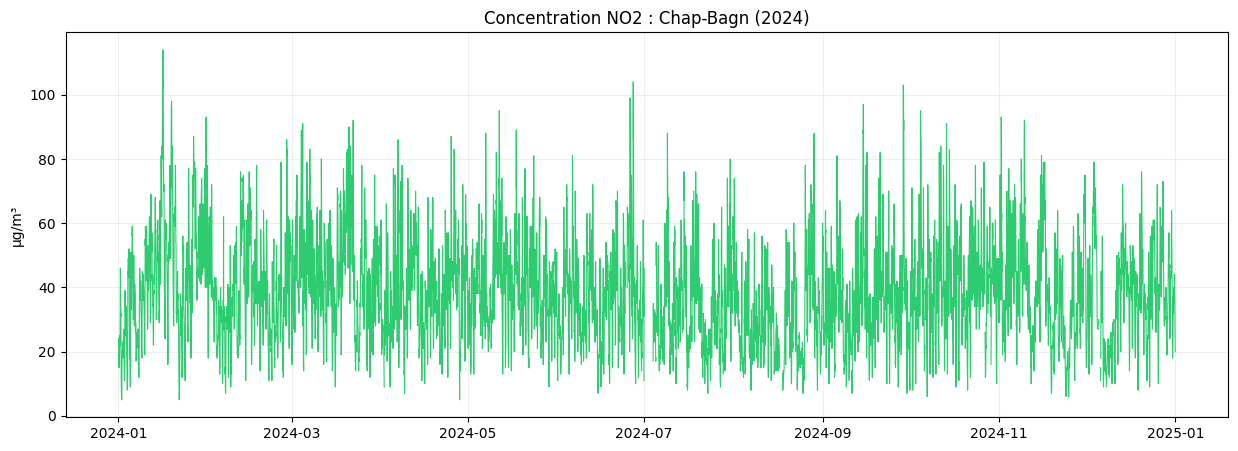

--- TYPES DES COLONNES ---
time         datetime64[ns]
Chap-Bagn           float64
Bagn-Berc           float64
Berc-Ital           float64
Ital-A6a            float64
A6a-Sevr            float64
Sevr-Aute           float64
Aute-Mail           float64
Mail-Chap           float64
dtype: object


--- NOMBRE DE VALEURS NULLES ---
time           0
Chap-Bagn    168
Bagn-Berc    168
Berc-Ital    168
Ital-A6a     168
A6a-Sevr     168
Sevr-Aute    168
Aute-Mail    168
Mail-Chap    168
dtype: int64

--- POURCENTAGE DE VALEURS NULLES ---
time         0.000000
Chap-Bagn    1.912568
Bagn-Berc    1.912568
Berc-Ital    1.912568
Ital-A6a     1.912568
A6a-Sevr     1.912568
Sevr-Aute    1.912568
Aute-Mail    1.912568
Mail-Chap    1.912568
dtype: float64


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
from pathlib import Path

# =============================================================
# 1. NAVIGATION DYNAMIQUE DES CHEMINS
# =============================================================
# On récupère l'emplacement actuel (le dossier 'notebooks')
current_dir = Path(os.getcwd())

# Si on est dans 'notebooks', on remonte au parent pour trouver 'data'
if current_dir.name == 'notebooks':
    base_path = current_dir.parent
else:
    base_path = current_dir

data_dir = base_path / 'data'
file_name = '2024_NO2_boulevard_périphérique.csv'
file_path = data_dir / file_name

print(f"📂 Dossier de recherche : {data_dir.absolute()}")

# =============================================================
# 2. VÉRIFICATION ET CHARGEMENT
# =============================================================
if not file_path.exists():
    print(f"❌ Erreur : Le fichier '{file_name}' est introuvable.")
    print(f"🔍 Contenu actuel du dossier data :")
    try:
        for f in data_dir.iterdir():
            print(f"  - {f.name}")
    except FileNotFoundError:
        print("  - [Le dossier 'data' lui-même est introuvable à cette adresse]")
else:
    print(f"✅ Fichier trouvé ! Chargement en cours...")
    # engine='python' aide souvent avec les accents dans les noms de fichiers
    df = pd.read_csv(file_path, sep=",", engine='python')
    df['time'] = pd.to_datetime(df['time'], errors='coerce')
    
    # --- Premières stats ---
    print("\n--- DIMENSIONS ---")
    print(f"{df.shape[0]} lignes, {df.shape[1]} colonnes")
    
    print("\n--- STATISTIQUES DES POLLUANTS ---")
    # On exclut la colonne 'time' pour les stats numériques
    display(df.drop(columns=['time']).describe())

    # =============================================================
    # 3. VISUALISATION RAPIDE
    # =============================================================
    plt.figure(figsize=(15, 5))
    # On prend un segment au hasard (ex: Porte de la Chapelle vers Bagnolet)
    plt.plot(df['time'], df['Chap-Bagn'], color='#2ecc71', linewidth=0.8)
    plt.title(f"Concentration NO2 : Chap-Bagn (2024)")
    plt.ylabel("µg/m³")
    plt.grid(True, alpha=0.2)
    plt.show()

    # 1. Afficher les types de données pour chaque colonne
    print("--- TYPES DES COLONNES ---")
    print(df.dtypes)

    print("\n" + "="*30 + "\n")

    # 2. Afficher le nombre de valeurs nulles (NaN) pour chaque colonne
    print("--- NOMBRE DE VALEURS NULLES ---")
    null_counts = df.isnull().sum()
    print(null_counts)

    #Afficher le pourcentage de valeurs manquantes (plus parlant)
    print("\n--- POURCENTAGE DE VALEURS NULLES ---")
    print((df.isnull().sum() / len(df)) * 100)

    

## Dictionnaire des Données - Qualité de l'Air Périphérique

Ce dataset contient les mesures horaires des concentrations de polluants atmosphériques sur différents segments du Boulevard Périphérique de Paris.

### Référence Temporelle
* **`time`** : Horodatage de la mesure (Format: AAAA-MM-JJ HH:MM:SS). 

### Segments du Périphérique (Localisation Spatiale)
Chaque colonne représente la concentration moyenne de polluants (en **µg/m³**) sur un tronçon spécifique :

| Colonne | Segment (De $\rightarrow$ Vers) | Zone Géographique |
| :--- | :--- | :--- |
| **Chap-Bagn** | Porte de la Chapelle $\rightarrow$ Porte de Bagnolet | Nord-Est |
| **Bagn-Berc** | Porte de Bagnolet $\rightarrow$ Porte de Bercy | Est |
| **Berc-Ital** | Porte de Bercy $\rightarrow$ Porte d'Italie | Sud-Est |
| **Ital-A6a** | Porte d'Italie $\rightarrow$ Jonction A6a | Sud |
| **A6a-Sevr** | Jonction A6a $\rightarrow$ Porte de Sèvres | Sud-Ouest |
| **Sevr-Aute** | Porte de Sèvres $\rightarrow$ Porte d'Auteuil | Ouest |
| **Aute-Mail** | Porte d'Auteuil $\rightarrow$ Porte de Maillot | Nord-Ouest (16e) |
| **Mail-Chap** | Porte de Maillot $\rightarrow$ Porte de la Chapelle | Nord-Ouest (17e) |

### Polluants Étudiés (Selon le fichier chargé)
* **NO2** : Dioxyde d'azote (lié principalement au trafic routier).
* **PM10** : Particules fines de diamètre inférieur à 10 micromètres.
* **PM2.5** : Particules fines de diamètre inférieur à 2.5 micromètres.

📂 Recherche des fichiers dans : c:\Users\louni\projetEtudeM2\smart-mobility-paris-m2-project\data

EXPLORATION - NO2

📊 Dimensions: 1944 lignes × 9 colonnes

📅 Période: 2026-01-01 00:00:00 à 2026-03-22 23:00:00

💾 Empreinte mémoire (en octets) :
Index          132
time         15552
Chap-Bagn    15552
Bagn-Berc    15552
Berc-Ital    15552
Ital-A6a     15552
A6a-Sevr     15552
Sevr-Aute    15552
Aute-Mail    15552
Mail-Chap    15552
dtype: int64

💾 Total mémoire : 0.13 MB

🔍 Valeurs manquantes:
time          0
Chap-Bagn    15
Bagn-Berc    15
Berc-Ital    15
Ital-A6a     15
A6a-Sevr     15
Sevr-Aute    15
Aute-Mail    15
Mail-Chap    15
dtype: int64


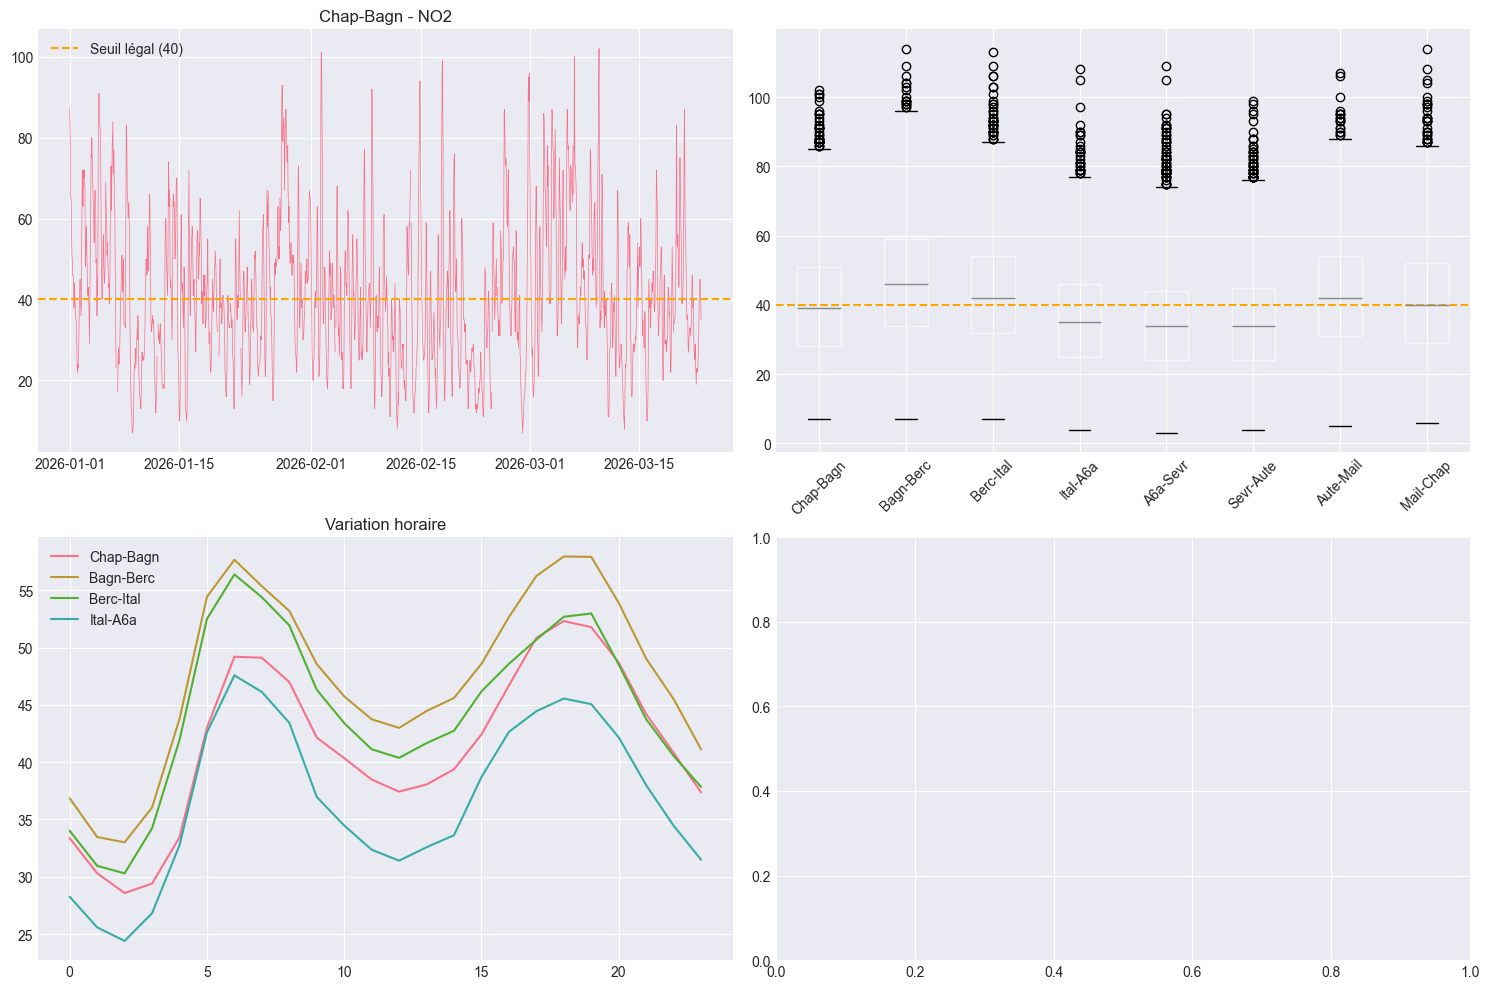

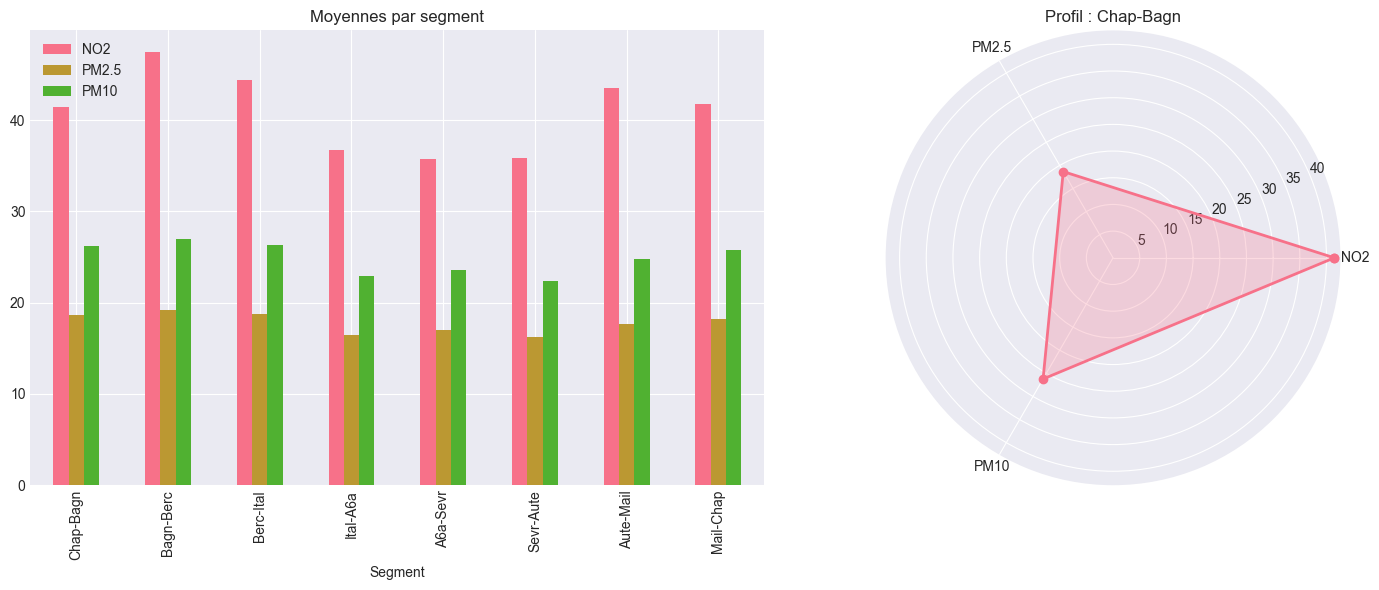

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
import os
from pathlib import Path
from math import pi

warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# =============================================================================
# 1. CHARGEMENT DES DONNÉES (CORRIGÉ POUR LES CHEMINS)
# =============================================================================

def charger_donnees():
    """Charge les trois fichiers de données avec gestion du chemin relatif"""
    # Gestion dynamique du chemin (remonte d'un cran si on est dans /notebooks)
    current_dir = Path(os.getcwd())
    base_path = current_dir.parent if current_dir.name == 'notebooks' else current_dir
    data_dir = base_path / 'data'

    print(f"📂 Recherche des fichiers dans : {data_dir.absolute()}")

    # Noms exacts des fichiers (attention aux accents)
    files = {
        'NO2':  data_dir / '2026_NO2_boulevard_périphérique.csv',
        'PM25': data_dir / '2026_PM25_boulevard_périphérique.csv',
        'PM10': data_dir / '2026_PM10_boulevard_périphérique.csv'
    }

    try:
        df_no2 = pd.read_csv(files['NO2'], parse_dates=['time'])
        df_pm25 = pd.read_csv(files['PM25'], parse_dates=['time'])
        df_pm10 = pd.read_csv(files['PM10'], parse_dates=['time'])
        return df_no2, df_pm25, df_pm10
    except FileNotFoundError as e:
        print(f"❌ Erreur : {e}")
        print(f"Contenu du dossier data : {[f.name for f in data_dir.glob('*.csv')]}")
        return None, None, None

# =============================================================================
# 2. EXPLORATION GÉNÉRALE (CORRIGÉ AVEC MÉMOIRE)
# =============================================================================

def exploration_generale(df, nom_polluant):
    if df is None: return
    print(f"\n{'='*60}")
    print(f"EXPLORATION - {nom_polluant}")
    print(f"{'='*60}")
    
    print(f"\n📊 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
    print(f"\n📅 Période: {df['time'].min()} à {df['time'].max()}")
    
    print(f"\n💾 Empreinte mémoire (en octets) :\n{df.memory_usage(deep=True)}")
    print(f"\n💾 Total mémoire : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print(f"\n🔍 Valeurs manquantes:\n{df.isnull().sum()}")

# =============================================================================
# 3. VISUALISATION TEMPORELLE (CORRIGÉ AVEC SEUILS)
# =============================================================================

def visualisation_temporelle(df, nom_polluant):
    if df is None: return
    segments = [col for col in df.columns if col not in ['time', 'heure', 'jour_semaine', 'jour']]
    
    # --- PLOTLY (Interactif) ---
    fig = make_subplots(rows=2, cols=1, vertical_spacing=0.12)
    for segment in segments:
        fig.add_trace(go.Scatter(x=df['time'], y=df[segment], name=segment), row=1, col=1)
    
    # Ajout ligne de seuil sur Plotly
    seuil = 40 if nom_polluant == 'NO2' else (50 if nom_polluant == 'PM10' else 20)
    fig.add_hline(y=seuil, line_dash="dash", line_color="orange", annotation_text="Seuil légal")
    
    fig.show()
    
    # --- MATPLOTLIB (Statique avec Seuils) ---
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Série temporelle + Seuil
    axes[0, 0].plot(df['time'], df[segments[0]], linewidth=0.5)
    axes[0, 0].axhline(y=seuil, color='orange', linestyle='--', label=f'Seuil légal ({seuil})')
    axes[0, 0].set_title(f'{segments[0]} - {nom_polluant}')
    axes[0, 0].legend()

    # 2. Boxplot
    df[segments].boxplot(ax=axes[0, 1], rot=45)
    axes[0, 1].axhline(y=seuil, color='orange', linestyle='--')
    
    # 3 & 4. Variation Horaire / Hebdomadaire
    df['heure'] = df['time'].dt.hour
    moy_h = df.groupby('heure')[segments].mean()
    for s in segments[:4]: axes[1, 0].plot(moy_h.index, moy_h[s], label=s)
    axes[1, 0].set_title('Variation horaire')
    axes[1, 0].legend()
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# 7. COMPARAISON (CORRIGÉ : RADAR CHART FIX)
# =============================================================================

def comparaison_polluants(df_no2, df_pm25, df_pm10):
    if df_no2 is None: return
    segments = [col for col in df_no2.columns if col not in ['time', 'heure', 'jour_semaine', 'jour']]
    
    moyennes = pd.DataFrame({
        'Segment': segments,
        'NO2': [df_no2[s].mean() for s in segments],
        'PM2.5': [df_pm25[s].mean() for s in segments],
        'PM10': [df_pm10[s].mean() for s in segments]
    })

    # FIX DU RADAR CHART : Création d'une figure spécifique
    fig = plt.figure(figsize=(15, 6))
    
    # Bar plot
    ax1 = fig.add_subplot(121)
    moyennes.plot(kind='bar', x='Segment', ax=ax1)
    ax1.set_title("Moyennes par segment")

    # Radar chart
    ax2 = fig.add_subplot(122, projection='polar')
    categories = ['NO2', 'PM2.5', 'PM10']
    N = len(categories)
    
    # Valeurs pour le premier segment
    values = moyennes.loc[0, categories].values.flatten().tolist()
    values += values[:1] # Fermer le cercle
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]
    
    ax2.plot(angles, values, 'o-', linewidth=2)
    ax2.fill(angles, values, alpha=0.25)
    ax2.set_xticks(angles[:-1])
    ax2.set_xticklabels(categories)
    ax2.set_title(f"Profil : {moyennes.loc[0, 'Segment']}")
    
    plt.tight_layout()
    plt.show()

# =============================================================================
# EXÉCUTION
# =============================================================================

if __name__ == "__main__":
    df_no2, df_pm25, df_pm10 = charger_donnees()
    
    if df_no2 is not None:
        exploration_generale(df_no2, "NO2")
        visualisation_temporelle(df_no2, "NO2")
        comparaison_polluants(df_no2, df_pm25, df_pm10)
        # Note : tu peux appeler les autres fonctions (analyse_spatiale, etc.) de la même manière